# Monte Carlo

### De un partido a 10,000 escenarios

Cada escenario avanza minuto a minuto. La intensidad ofensiva se adapta al reloj y a lo que está ocurriendo en esa trayectoria; después se generan ocasiones con Poisson y cada ocasión se convierte o no en gol según su xG. La semilla `28055` hace que las 10,000 simulaciones sean reproducibles.

In [17]:
from collections import Counter
from itertools import product
from pathlib import Path
import pickle
import warnings

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import pandas as pd
from patsy import dmatrix
import xgboost as xgb
from IPython.display import display

warnings.filterwarnings("ignore", category=UserWarning)

BLUE = "#2563EB"
BLUE_LIGHT = "#BFDBFE"
GOLD = "#D89B19"
GOLD_LIGHT = "#FDE7A9"
INK = "#1F2937"
MUTED = "#6B7280"
GRID = "#E5E7EB"
PAPER = "#FCFCFA"
GREY = "#9CA3AF"

plt.rcParams.update({
    "figure.facecolor": PAPER, "axes.facecolor": PAPER, "axes.edgecolor": GRID,
    "axes.labelcolor": INK, "text.color": INK, "xtick.color": MUTED,
    "ytick.color": MUTED, "font.size": 11.5, "axes.titleweight": "bold",
})

def clean_axes(ax, grid_axis="y"):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis=grid_axis, color=GRID, linewidth=0.8, alpha=0.8)
    ax.set_axisbelow(True)

def finish_chart(fig, subtitle, y=0.90):
    fig.text(0.06, y, subtitle, fontsize=10.3, color=MUTED, ha="left")

data_candidates = [Path("../02_data"), Path("02_data")]
DATA_DIR = next((path for path in data_candidates if path.exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError("No se encontró 02_data")
MATCH_ID = 28055
MATCH_DATE = pd.Timestamp("2025-05-11")
SEED = 28055
N_SIMS = 10_000
MEAN_XG_SHOT = 0.10

context = pd.read_csv(DATA_DIR / "contextual_rag.csv", encoding="utf-8-sig")
context["date"] = pd.to_datetime(context["date"])
segments = pd.read_csv(DATA_DIR / "clasico_contextual_segments.csv", encoding="utf-8-sig")
subs = pd.read_csv(DATA_DIR / "substitutions_barca_real_madrid.csv", encoding="utf-8-sig")
subs["match_date"] = pd.to_datetime(subs["match_date"])
predictions = pd.read_excel(DATA_DIR / "predictions.xlsx")

clasico = subs[subs["match_id"] == MATCH_ID].copy()
history = subs[subs["match_date"] < MATCH_DATE].copy()
import pickle
import numpy as np
import pandas as pd
from patsy import dmatrix


def load_model(path):
    with open(path, 'rb') as file:
        artifact = pickle.load(file)
    assert artifact['df'] == 3 and artifact['degree'] == 2
    return artifact


def predict_model(artifact, values):
    values = np.clip(np.asarray(values, dtype=float).reshape(-1), 0, 1)
    matrix = np.asarray(dmatrix(artifact['formula'], {artifact['feature']: values}))
    assert matrix.shape[1] == artifact['model'].n_features_in_
    matrix = pd.DataFrame(matrix, columns=artifact['model'].feature_names_in_)
    return artifact['model'].predict(matrix)




In [18]:
required_sub_columns = {
    "match_id", "match_date", "team", "player_id", "sub_in", "sub_out",
    "match_minutes_played", "in_status", "out_status", "off_xg_coef",
    "def_xg_coef", "fatigue", "rhythm",
}
assert required_sub_columns.issubset(subs.columns)
assert not subs.duplicated(["match_id", "player_id"]).any()
assert set(clasico["team"]) == {"Barcelona", "Real Madrid"}
assert len(clasico) == 44
assert context[context["match_id"] == MATCH_ID].shape[0] > 0
assert MATCH_ID not in set(predictions.get("match_id", pd.Series(dtype=int)).dropna().astype(int))

def match_pools(team):
    rows = clasico[clasico["team"] == team]
    starters = rows.loc[
        rows["sub_in"].isna() & (rows["match_minutes_played"] > 0), "player_id"
    ].tolist()
    bench = rows.loc[~rows["player_id"].isin(starters), "player_id"].tolist()
    return starters, bench

home_starters, home_bench = match_pools("Barcelona")
away_starters, away_bench = match_pools("Real Madrid")
assert len(home_starters) == len(away_starters) == 11

In [19]:
EXPECTED_FEATURES = [
    "elevation_dif", "travel", "is_home",
    "match_state_-0.5", "match_state_-1.5", "match_state_0.0",
    "match_state_0.5", "match_state_1.5",
    "player_dif_-0.5", "player_dif_-1.5", "player_dif_0.0",
    "player_dif_0.5", "player_dif_1.5",
    "time_segment_1", "time_segment_2", "time_segment_3",
    "time_segment_4", "time_segment_5", "time_segment_6",
]

booster = xgb.Booster()
booster.load_model(DATA_DIR / "crag_booster.json")
assert booster.feature_names == EXPECTED_FEATURES

clasico_context = context[context["match_id"] == MATCH_ID].sort_values("first_segment_id")
meta = clasico_context.iloc[0]
first_segment = segments.sort_values("segment_id").iloc[0]
HOME_FR_START = float(first_segment["teamA_fr_rag"] / first_segment["minutes_played"] * 90)
AWAY_FR_START = float(first_segment["teamB_fr_rag"] / first_segment["minutes_played"] * 90)

def category_text(value):
    value = float(value)
    return "0.0" if value == 0 else str(value)

def encode_context(frame):
    encoded = frame.copy()
    for column in ["match_state", "player_dif"]:
        encoded[column] = encoded[column].map(category_text)
    encoded["time_segment"] = encoded["time_segment"].astype(int).astype(str)
    encoded["is_home"] = encoded["is_home"].astype(int)
    cats = pd.get_dummies(
        encoded[["match_state", "player_dif", "time_segment"]],
        prefix=["match_state", "player_dif", "time_segment"],
    )
    matrix = pd.concat([
        encoded[["elevation_dif", "travel", "is_home"]].reset_index(drop=True),
        cats.reset_index(drop=True),
    ], axis=1)
    return matrix.reindex(columns=EXPECTED_FEATURES, fill_value=0).astype(float)

def contextual_prediction(frame):
    matrix = encode_context(frame)
    margin = np.log(frame["fr_rag90"].clip(lower=0.01).to_numpy())
    return booster.predict(xgb.DMatrix(matrix, base_margin=margin))

def scenario_frame(is_home, fr_rag90, state=0.0, player_dif=0.0, segment=1):
    return pd.DataFrame([{
        "fr_rag90": fr_rag90,
        "is_home": int(is_home),
        "elevation_dif": meta["home_elevation_dif"] if is_home else meta["away_elevation_dif"],
        "travel": -meta["away_travel"] if is_home else meta["away_travel"],
        "match_state": state,
        "player_dif": player_dif,
        "time_segment": segment,
    }])

home_kickoff = float(contextual_prediction(scenario_frame(True, HOME_FR_START))[0])
away_kickoff = float(contextual_prediction(scenario_frame(False, AWAY_FR_START))[0])
assert home_kickoff > 0 and away_kickoff > 0

In [20]:
STATES = [-1.5, -0.5, 0.0, 0.5, 1.5]
PLAYER_DIFFS = [-1.5, -0.5, 0.0, 0.5, 1.5]
SEGMENTS = range(1, 7)

context_multiplier = {"home": {}, "away": {}}
for side, is_home in [("home", True), ("away", False)]:
    frames, keys = [], []
    for state, player_dif, segment in product(STATES, PLAYER_DIFFS, SEGMENTS):
        frames.append(scenario_frame(is_home, 1.0, state, player_dif, segment).iloc[0])
        keys.append((state, player_dif, segment))
    batch = pd.DataFrame(frames)
    values = contextual_prediction(batch)
    context_multiplier[side] = dict(zip(keys, values))

assert np.isclose(HOME_FR_START * context_multiplier["home"][(0.0, 0.0, 1)], home_kickoff)
assert np.isclose(AWAY_FR_START * context_multiplier["away"][(0.0, 0.0, 1)], away_kickoff)

In [21]:
rhythm_artifact = load_model(DATA_DIR / "rhythm_model.pkl")
fatigue_artifact = load_model(DATA_DIR / "fatigue_model.pkl")
player_rows = clasico.set_index("player_id")
off_90 = (player_rows["off_xg_coef"].fillna(0).to_numpy() + predict_model(rhythm_artifact, player_rows["rhythm"].fillna(0))) * 90
def_90 = (player_rows["def_xg_coef"].fillna(0).to_numpy() + predict_model(fatigue_artifact, player_rows["fatigue"].fillna(0))) * 90
player_strength = {player: {"off": float(off), "def": float(defense)} for player, off, defense in zip(player_rows.index, off_90, def_90)}

STATUS_ORDER = ["trailing", "level", "leading"]
TACTICAL_WEIGHTS = {
    "Trailing": (0.8, 0.2),
    "Level": (0.5, 0.5),
    "Leading": (0.2, 0.8),
}

def laplace_status_probability(events, status):
    counts = events.dropna().astype(str).str.lower().value_counts().reindex(STATUS_ORDER, fill_value=0) + 1
    return float(counts[status.lower()] / counts.sum())

def player_profile(player_id):
    old = history[history["player_id"] == player_id]
    snapshot = player_rows.loc[player_id]
    return {
        "minutes": float(old["match_minutes_played"].sum()),
        "sub_in_count": int(old["sub_in"].notna().sum()),
        "sub_out_count": int(old["sub_out"].notna().sum()),
        "in_events": old.loc[old["sub_in"].notna(), "in_status"],
        "out_events": old.loc[old["sub_out"].notna(), "out_status"],
        "off_coef": 0.0 if pd.isna(snapshot["off_xg_coef"]) else float(snapshot["off_xg_coef"]),
        "def_coef": 0.0 if pd.isna(snapshot["def_xg_coef"]) else float(snapshot["def_xg_coef"]),
    }

profiles = {player_id: player_profile(player_id) for player_id in player_rows.index}

def raw_sub_score(player_id, status, mode):
    profile = profiles[player_id]
    off_weight, def_weight = TACTICAL_WEIGHTS[status]
    events = profile[f"{mode}_events"]
    history_count = profile[f"sub_{mode}_count"]
    status_probability = laplace_status_probability(events, status)
    tactical = profile["off_coef"] * off_weight + profile["def_coef"] * def_weight
    tactical_base = max(0.001, 0.1 + tactical)
    if mode == "out":
        hierarchy = 1 / ((profile["minutes"] / 100) + 1) ** 2
        tactical_factor = 1 / tactical_base
    else:
        hierarchy = (profile["minutes"] / 100) + 1
        tactical_factor = tactical_base
    return (history_count + 1) * status_probability * hierarchy * tactical_factor

sub_scores = {
    (status, mode, player): raw_sub_score(player, status, mode)
    for status in TACTICAL_WEIGHTS
    for mode in ["in", "out"]
    for player in player_rows.index
}

team_change_counts = (
    history.assign(change=history["sub_in"].notna().astype(int))
    .groupby(["team", "match_id"], as_index=False)["change"].sum()
)
change_count_values = {
    team: np.clip(rows["change"].to_numpy(dtype=int), 0, 5)
    for team, rows in team_change_counts.groupby("team")
}
minute_values = {
    team: rows["sub_in"].dropna().clip(upper=89).astype(int).to_numpy()
    for team, rows in history.groupby("team")
}

In [22]:
def normalized_probabilities(players, status, mode):
    weights = np.array([sub_scores[(status, mode, player)] for player in players], dtype=float)
    if not np.isfinite(weights).all() or weights.sum() <= 0:
        weights = np.ones(len(players), dtype=float)
    return weights / weights.sum()

def short_name(player_id):
    return player_id.rsplit("_", 2)[0]

GOALKEEPERS = {
    player_id for player_id in player_rows.index
    if short_name(player_id) in {"Iñaki Peña", "Marc-André ter Stegen", "Wojciech Szczęsny", "Andriy Lunin", "Thibaut Courtois"}
}

In [23]:
def score_state(goals_for, goals_against):
    difference = goals_for - goals_against
    if difference == 0:
        return 0.0
    if difference == 1:
        return 0.5
    if difference > 1:
        return 1.5
    if difference == -1:
        return -0.5
    return -1.5

def status_label(state):
    return "Leading" if state > 0 else "Trailing" if state < 0 else "Level"

def player_difference(team_size, opponent_size):
    difference = team_size - opponent_size
    if difference == 0:
        return 0.0
    if difference == 1:
        return 0.5
    if difference > 1:
        return 1.5
    if difference == -1:
        return -0.5
    return -1.5

def current_fr_rag(home_active, away_active):
    # La intensidad se actualiza con el contexto vigente de cada trayectoria.
    home_off_delta = sum(player_strength[p]["off"] for p in home_active) - sum(player_strength[p]["off"] for p in home_starters)
    home_def_delta = sum(player_strength[p]["def"] for p in home_active) - sum(player_strength[p]["def"] for p in home_starters)
    away_off_delta = sum(player_strength[p]["off"] for p in away_active) - sum(player_strength[p]["off"] for p in away_starters)
    away_def_delta = sum(player_strength[p]["def"] for p in away_active) - sum(player_strength[p]["def"] for p in away_starters)
    home_fr = HOME_FR_START + home_off_delta - away_def_delta
    away_fr = AWAY_FR_START + away_off_delta - home_def_delta
    return max(0.01, home_fr), max(0.01, away_fr)

def sample_schedule(rng, team):
    number = int(rng.choice(change_count_values[team]))
    if number == 0:
        return {}
    sampled = rng.choice(minute_values[team], size=number, replace=True)
    return dict(Counter(int(minute) for minute in sampled))

def weighted_pick(rng, players, status, mode, size):
    size = min(size, len(players))
    probabilities = normalized_probabilities(players, status, mode)
    return list(rng.choice(players, size=size, replace=False, p=probabilities))

def apply_substitutions(rng, active, bench, number, status):
    out_candidates = [player for player in active if player not in GOALKEEPERS]
    in_candidates = [player for player in bench if player not in GOALKEEPERS]
    number = min(number, len(out_candidates), len(in_candidates))
    if number <= 0:
        return active, bench, []
    outgoing = weighted_pick(rng, out_candidates, status, "out", number)
    incoming = weighted_pick(rng, in_candidates, status, "in", number)
    new_active = [player for player in active if player not in outgoing] + incoming
    new_bench = [player for player in bench if player not in incoming]
    events = list(zip(outgoing, incoming))
    return new_active, new_bench, events

def simulate_team_minute(rng, xg90):
    expected_shots = (xg90 / 90) / MEAN_XG_SHOT
    shots = int(rng.poisson(expected_shots))
    if shots == 0:
        return 0.0, 0
    shot_xg = rng.exponential(MEAN_XG_SHOT, size=shots)
    goal_probabilities = np.clip(shot_xg, 0, 1)
    goals = int((rng.random(shots) < goal_probabilities).sum())
    return float(shot_xg.sum()), goals

def simulate_match(sim_id, trace=False):
    rng = np.random.default_rng(SEED + sim_id * 100_003)
    home_schedule = sample_schedule(rng, "Barcelona")
    away_schedule = sample_schedule(rng, "Real Madrid")
    home_active, away_active = home_starters.copy(), away_starters.copy()
    home_inactive, away_inactive = home_bench.copy(), away_bench.copy()
    home_goals = away_goals = 0
    home_xg = away_xg = 0.0
    home_fr, away_fr = current_fr_rag(home_active, away_active)
    rows, goal_events, sub_events = [], [], []

    for minute in range(1, 91):
        segment = min((minute - 1) // 15 + 1, 6)
        home_state = score_state(home_goals, away_goals)
        away_state = score_state(away_goals, home_goals)

        if minute in home_schedule:
            home_active, home_inactive, changes = apply_substitutions(
                rng, home_active, home_inactive, home_schedule[minute], status_label(home_state)
            )
            sub_events.extend((minute, "Barcelona", short_name(out_), short_name(in_)) for out_, in_ in changes)
        if minute in away_schedule:
            away_active, away_inactive, changes = apply_substitutions(
                rng, away_active, away_inactive, away_schedule[minute], status_label(away_state)
            )
            sub_events.extend((minute, "Real Madrid", short_name(out_), short_name(in_)) for out_, in_ in changes)
        if minute in home_schedule or minute in away_schedule:
            home_fr, away_fr = current_fr_rag(home_active, away_active)

        home_pdiff = player_difference(len(home_active), len(away_active))
        away_pdiff = player_difference(len(away_active), len(home_active))
        home_xg90 = home_fr * context_multiplier["home"][(home_state, home_pdiff, segment)]
        away_xg90 = away_fr * context_multiplier["away"][(away_state, away_pdiff, segment)]

        home_minute_xg, home_minute_goals = simulate_team_minute(rng, home_xg90)
        away_minute_xg, away_minute_goals = simulate_team_minute(rng, away_xg90)
        home_xg += home_minute_xg
        away_xg += away_minute_xg
        if home_minute_goals:
            for _ in range(home_minute_goals):
                home_goals += 1
                goal_events.append((minute, "Barcelona", home_goals, away_goals))
        if away_minute_goals:
            for _ in range(away_minute_goals):
                away_goals += 1
                goal_events.append((minute, "Real Madrid", home_goals, away_goals))

        if trace:
            rows.append({
                "minute": minute, "home_goals": home_goals, "away_goals": away_goals,
                "home_xg": home_xg, "away_xg": away_xg,
                "home_xg90": home_xg90, "away_xg90": away_xg90,
                "home_fr_rag": home_fr, "away_fr_rag": away_fr,
                "segment": segment, "home_state": home_state, "away_state": away_state,
                "home_lineup": tuple(home_active), "away_lineup": tuple(away_active),
            })

    result = {
        "sim_id": sim_id, "home_goals": home_goals, "away_goals": away_goals,
        "home_xg": home_xg, "away_xg": away_xg,
        "home_subs": sum(home_schedule.values()), "away_subs": sum(away_schedule.values()),
    }
    if trace:
        result.update({"timeline": pd.DataFrame(rows), "goals": goal_events, "subs": sub_events})
    return result

In [24]:
simulation = pd.DataFrame(simulate_match(sim_id) for sim_id in range(N_SIMS))
simulation["outcome"] = np.select(
    [
        simulation["home_goals"] > simulation["away_goals"],
        simulation["home_goals"] == simulation["away_goals"],
    ],
    ["Barcelona", "Empate"],
    default="Real Madrid",
)
simulation["total_goals"] = simulation["home_goals"] + simulation["away_goals"]

outcome_order = ["Barcelona", "Empate", "Real Madrid"]
probabilities = simulation["outcome"].value_counts(normalize=True).reindex(outcome_order)

assert len(simulation) == N_SIMS
assert np.isfinite(simulation.select_dtypes("number")).all().all()
assert np.isclose(probabilities.sum(), 1.0)


## Una trayectoria aleatoria

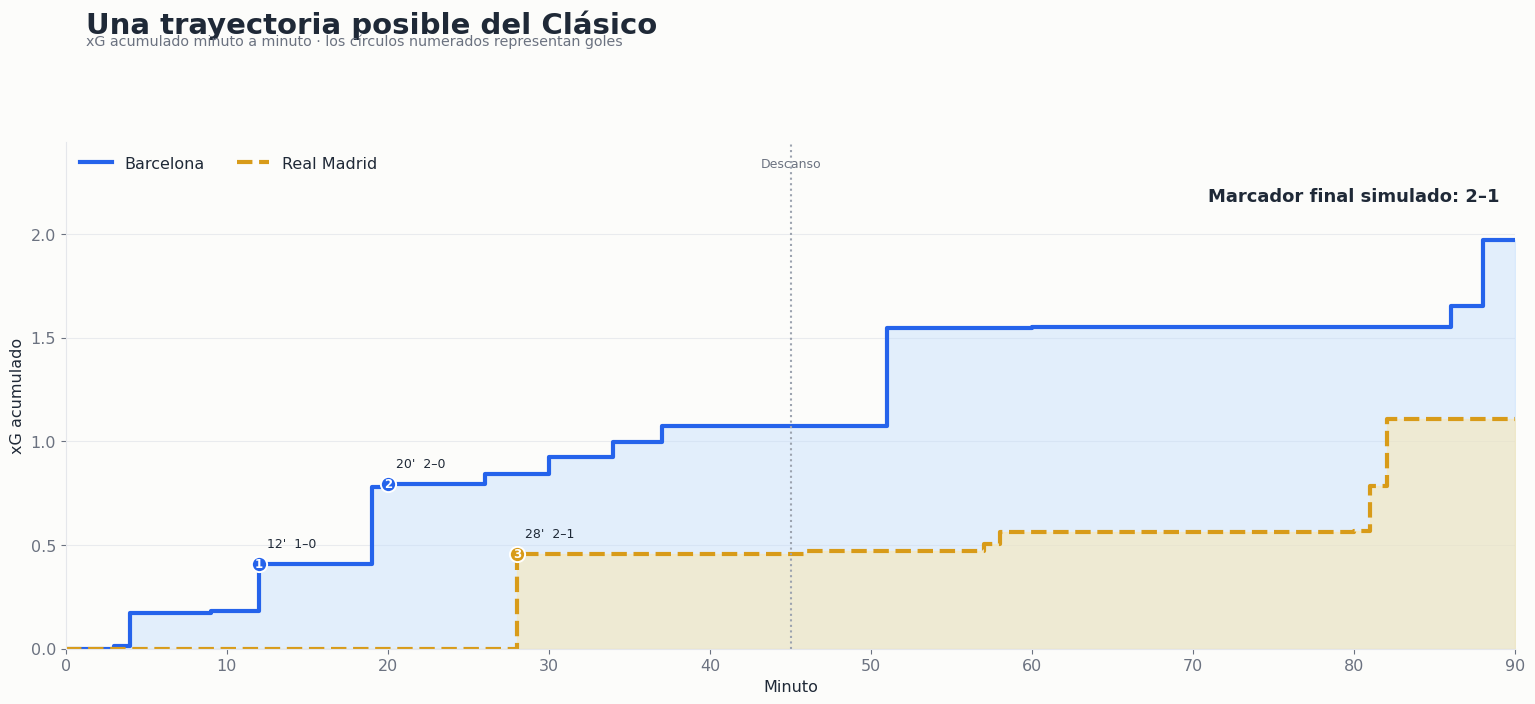

In [39]:
# Cada ejecucion elige al azar entre todas las simulaciones.
representative_id = int(np.random.default_rng().choice(simulation["sim_id"].to_numpy()))
representative = simulate_match(representative_id, trace=True)
trace = representative["timeline"]

assert trace["home_xg90"].nunique() > 1
assert trace["away_xg90"].nunique() > 1
assert trace["segment"].nunique() == 6

fig, ax = plt.subplots(figsize=(15.5, 7.2))
minutes = np.r_[0, trace["minute"].to_numpy()]
home_cum = np.r_[0, trace["home_xg"].to_numpy()]
away_cum = np.r_[0, trace["away_xg"].to_numpy()]

ax.step(minutes, home_cum, where="post", color=BLUE, lw=3.0, label="Barcelona")
ax.step(minutes, away_cum, where="post", color=GOLD, lw=3.0, linestyle="--", label="Real Madrid")
ax.fill_between(minutes, home_cum, step="post", color=BLUE_LIGHT, alpha=0.42)
ax.fill_between(minutes, away_cum, step="post", color=GOLD_LIGHT, alpha=0.48)

for number, (minute, team, home_score, away_score) in enumerate(representative["goals"], start=1):
    column = "home_xg" if team == "Barcelona" else "away_xg"
    y_value = float(trace.loc[trace["minute"] == minute, column].iloc[0])
    color = BLUE if team == "Barcelona" else GOLD
    ax.scatter(minute, y_value, s=120, color=color, edgecolor="white", linewidth=1.4, zorder=4)
    ax.text(
        minute, y_value, str(number), color="white", ha="center", va="center",
        fontsize=8.5, fontweight="bold", zorder=5,
    )
    ax.annotate(
        f"{minute}'  {home_score}–{away_score}", (minute, y_value), xytext=(6, 12),
        textcoords="offset points", fontsize=9, color=INK,
    )

ax.axvline(45, color=GREY, linestyle=":", lw=1.5)
y_max = max(home_cum[-1], away_cum[-1]) * 1.24
ax.text(45, y_max * 0.97, "Descanso", ha="center", va="top", color=MUTED, fontsize=9)
ax.set_xlim(0, 90)
ax.set_ylim(0, y_max)
ax.set_xlabel("Minuto")
ax.set_ylabel("xG acumulado")
ax.legend(frameon=False, ncol=2, loc="upper left")
ax.text(
    89, y_max * 0.91,
    f"Marcador final simulado: {representative['home_goals']}–{representative['away_goals']}",
    ha="right", va="top", fontsize=13, fontweight="bold",
)
clean_axes(ax)

fig.suptitle(
    "Una trayectoria posible del Clásico",
    x=0.06, y=0.975, ha="left", fontsize=21, fontweight="bold", color=INK,
)
finish_chart(
    fig,
    "xG acumulado minuto a minuto · los círculos numerados representan goles",
    y=0.925,
)
plt.tight_layout(rect=(0, 0, 1, 0.88))
plt.show()

## Probabilidades después de 10,000 simulaciones

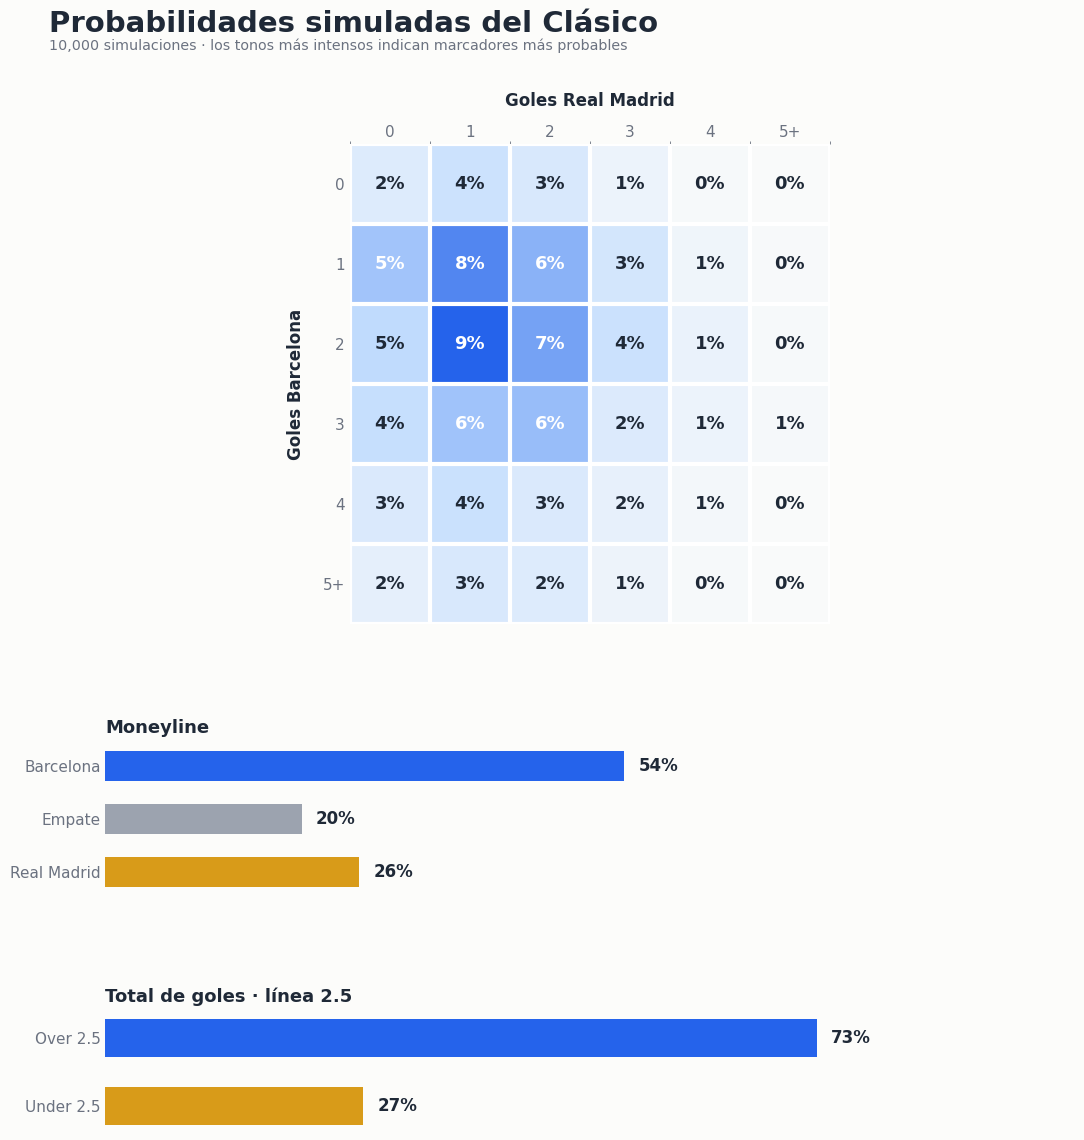

In [40]:
score_bins = list(range(6))
score_labels = ["0", "1", "2", "3", "4", "5+"]

score_matrix = (
    pd.crosstab(
        simulation["home_goals"].clip(upper=5),
        simulation["away_goals"].clip(upper=5),
    )
    .reindex(index=score_bins, columns=score_bins, fill_value=0)
    .div(N_SIMS)
)

moneyline_probabilities = probabilities.reindex(["Barcelona", "Empate", "Real Madrid"])
total_probabilities = pd.Series({
    "Over 2.5": (simulation["total_goals"] >= 3).mean(),
    "Under 2.5": (simulation["total_goals"] <= 2).mean(),
})

assert score_matrix.shape == (6, 6)
assert np.isclose(score_matrix.to_numpy().sum(), 1.0)
assert np.isclose(moneyline_probabilities.sum(), 1.0)
assert np.isclose(total_probabilities.sum(), 1.0)
assert int((score_matrix * N_SIMS).to_numpy().sum()) == N_SIMS

probability_cmap = LinearSegmentedColormap.from_list(
    "probability_blues", [PAPER, BLUE_LIGHT, BLUE]
)

fig = plt.figure(figsize=(12.5, 12.8))
grid = fig.add_gridspec(3, 1, height_ratios=[7.2, 2.25, 1.75], hspace=0.48)

heat_ax = fig.add_subplot(grid[0])
matrix_values = score_matrix.to_numpy()
max_probability = float(matrix_values.max())
heat_ax.imshow(
    matrix_values,
    cmap=probability_cmap,
    vmin=0,
    vmax=max_probability,
    interpolation="nearest",
    aspect="equal",
)

heat_ax.set_xticks(range(6), labels=score_labels)
heat_ax.set_yticks(range(6), labels=score_labels)
heat_ax.xaxis.tick_top()
heat_ax.xaxis.set_label_position("top")
heat_ax.set_xlabel("Goles Real Madrid", labelpad=13, fontsize=12, fontweight="bold")
heat_ax.set_ylabel("Goles Barcelona", labelpad=13, fontsize=12, fontweight="bold")
heat_ax.tick_params(axis="both", length=0, labelsize=11)

heat_ax.set_xticks(np.arange(-0.5, 6, 1), minor=True)
heat_ax.set_yticks(np.arange(-0.5, 6, 1), minor=True)
heat_ax.grid(which="minor", color="white", linewidth=3)
heat_ax.tick_params(which="minor", bottom=False, left=False)
for spine in heat_ax.spines.values():
    spine.set_visible(False)

for row in range(6):
    for column in range(6):
        value = matrix_values[row, column]
        text_color = "white" if value >= max_probability * 0.58 else INK
        heat_ax.text(
            column,
            row,
            f"{value:.0%}",
            ha="center",
            va="center",
            fontsize=13,
            fontweight="bold",
            color=text_color,
        )

def draw_probability_bars(ax, values, colors, title):
    positions = np.arange(len(values))
    ax.barh(positions, values.to_numpy(), color=colors, height=0.56)
    ax.set_yticks(positions, labels=values.index)
    ax.invert_yaxis()
    ax.set_xlim(0, 1)
    ax.set_title(title, loc="left", fontsize=13, fontweight="bold", pad=8)
    ax.set_xticks([])
    ax.tick_params(axis="y", length=0, labelsize=11)
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    for position, value in zip(positions, values.to_numpy()):
        ax.text(
            value + 0.015,
            position,
            f"{value:.0%}",
            va="center",
            ha="left",
            fontsize=12,
            fontweight="bold",
            color=INK,
        )

moneyline_ax = fig.add_subplot(grid[1])
draw_probability_bars(
    moneyline_ax,
    moneyline_probabilities,
    [BLUE, GREY, GOLD],
    "Moneyline",
)

total_ax = fig.add_subplot(grid[2])
draw_probability_bars(
    total_ax,
    total_probabilities,
    [BLUE, GOLD],
    "Total de goles · línea 2.5",
)

fig.suptitle(
    "Probabilidades simuladas del Clásico",
    x=0.08,
    y=0.985,
    ha="left",
    fontsize=21,
    fontweight="bold",
    color=INK,
)
fig.text(
    0.08,
    0.954,
    "10,000 simulaciones · los tonos más intensos indican marcadores más probables",
    fontsize=10.3,
    color=MUTED,
    ha="left",
)
plt.show()

repeat_a = simulate_match(137)
repeat_b = simulate_match(137)
assert repeat_a == repeat_b
